In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import time
from numpy.random import Generator, MT19937

# Initialize random number generator
seed = int(time.time())
rng = Generator(MT19937(seed))

# Metropolis Hastings functions

In [2]:
# User-defined target PDF (multivariate standard normal by default)
def target_pdf(x):
    x = np.asarray(x)
    return np.exp(-0.5 * np.sum(x**2, axis=-1)) / (2 * np.pi) ** (x.shape[-1]/2)

# User-defined function to integrate (default: exp(-sum(x**2)))
def f(x):
    x = np.asarray(x)
    return np.exp(-np.sum(x**2, axis=-1))

# Multidimensional Metropolis-Hastings sampler
def metropolis_hastings(x0, thinning, burnin, N, step_size, target_pdf):
    d = len(x0)
    samples = []
    x_current = np.array(x0)
    for _ in range(N):
        x_proposed = x_current + rng.uniform(-step_size, step_size, size=d)
        acceptance_ratio = target_pdf(x_proposed) / target_pdf(x_current)
        if np.random.rand() < acceptance_ratio:
            x_current = x_proposed
        samples.append(x_current.copy())
    samples = samples[::thinning] #Keep every 'thinning'-th sample
    samples = samples[burnin:] #Discard the firs 'burnin' samples
    return np.array(samples)

# Importance sampling integration for multidimensional case
def importance_integration(f, target_pdf, m_chain):
    weights = f(m_chain) / target_pdf(m_chain)
    estimate = np.mean(weights)
    return estimate

# Uniform Functions

In [3]:
# User-defined function to integrate (default: exp(-sum(x**2)))
def integrand(x):
    x = np.asarray(x)
    return np.exp(-np.sum(x**2, axis=-1))

# Monte Carlo integration for multidimensional case
def monte_carlo_integral(integrand, bounds, N):
    d = len(bounds[0])
    low = np.array(bounds[0])
    high = np.array(bounds[1])
    samples = np.random.uniform(low, high, size=(N, d))
    vol = np.prod(high - low)
    values = integrand(samples)
    estimate = vol * np.mean(values)
    std_error = vol * np.std(values) / np.sqrt(N)
    return estimate, std_error

# Gaussian Integral in 8D: Uniform vs Metropolis-Hastings
This cell computes the value of the 8D Gaussian integral for different N using both Uniform Monte Carlo and Metropolis-Hastings, and plots the results.

In [16]:
D = 8
N_values = np.logspace(2, 6, 15, dtype=int)  # 100 to 1,000,000
actual_value = np.pi ** (D / 2)

# Uniform Monte Carlo
uniform_estimates = []
for N in N_values:
    bounds = [np.full(D, -3.5), np.full(D, 3.5)]
    estimate, _ = monte_carlo_integral(integrand, bounds, N)
    uniform_estimates.append(estimate)

# Metropolis-Hastings
mh_estimates = []
for N in N_values:
    x0 = np.zeros(D)
    step_size = 1.0
    thinning = 1
    burnin = int(0.1 * N)
    m_chain = metropolis_hastings(x0, thinning, burnin, N, step_size, target_pdf)
    estimate = importance_integration(f, target_pdf, m_chain)
    mh_estimates.append(estimate)

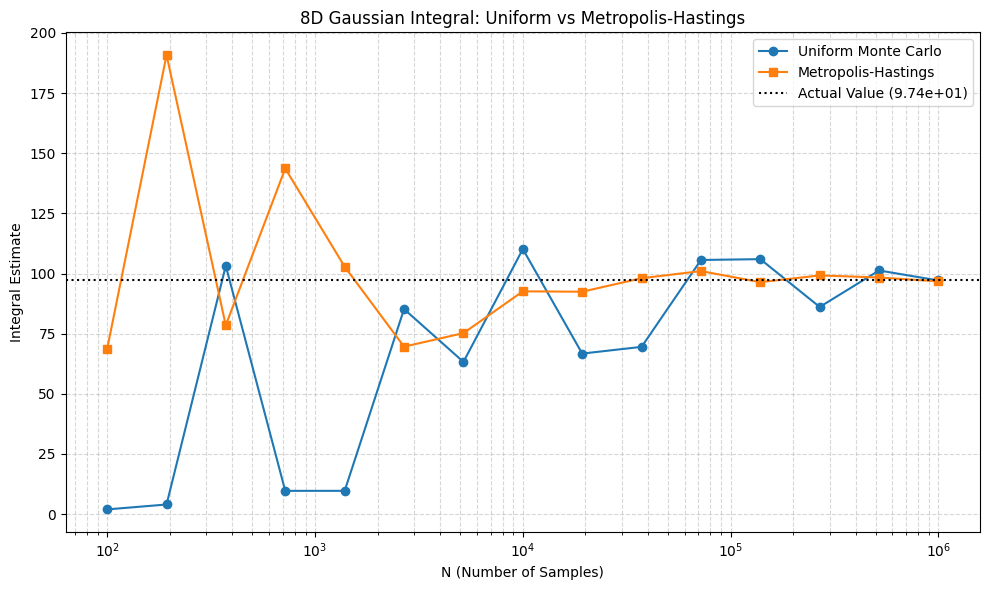

In [17]:

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(N_values, uniform_estimates, marker='o', label='Uniform Monte Carlo', color='tab:blue')
plt.plot(N_values, mh_estimates, marker='s', label='Metropolis-Hastings', color='tab:orange')
plt.axhline(actual_value, color='k', linestyle=':', label=f'Actual Value ({actual_value:.2e})')
plt.xscale('log')
plt.xlabel('N (Number of Samples)')
plt.ylabel('Integral Estimate')
plt.title('8D Gaussian Integral: Uniform vs Metropolis-Hastings')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Gaussian Integral in 8D: Uniform vs Metropolis-Hastings (Mean and Error Bars)
This cell computes the value of the 8D Gaussian integral for different N using both Uniform Monte Carlo and Metropolis-Hastings, runs each estimator multiple times, and plots the mean and error bars for each method.

In [24]:
D = 8
N_values = np.logspace(2, 6, 15, dtype=int)  # 100 to 1,000,000
actual_value = np.pi ** (D / 2)
num_repeats = 5  # Number of runs per N value

# Uniform Monte Carlo
uniform_means = []
uniform_stds = []
for N in N_values:
    estimates = []
    bounds = [np.full(D, -3.5), np.full(D, 3.5)]
    for _ in range(num_repeats):
        estimate, _ = monte_carlo_integral(integrand, bounds, N)
        estimates.append(estimate)
    uniform_means.append(np.mean(estimates))
    uniform_stds.append(np.std(estimates, ddof=1))

# Metropolis-Hastings
mh_means = []
mh_stds = []
for N in N_values:
    estimates = []
    for _ in range(num_repeats):
        x0 = np.zeros(D)
        step_size = 1.0
        thinning = 1
        burnin = int(0.1 * N)
        m_chain = metropolis_hastings(x0, thinning, burnin, N, step_size, target_pdf)
        estimate = importance_integration(f, target_pdf, m_chain)
        estimates.append(estimate)
    mh_means.append(np.mean(estimates))
    mh_stds.append(np.std(estimates, ddof=1))

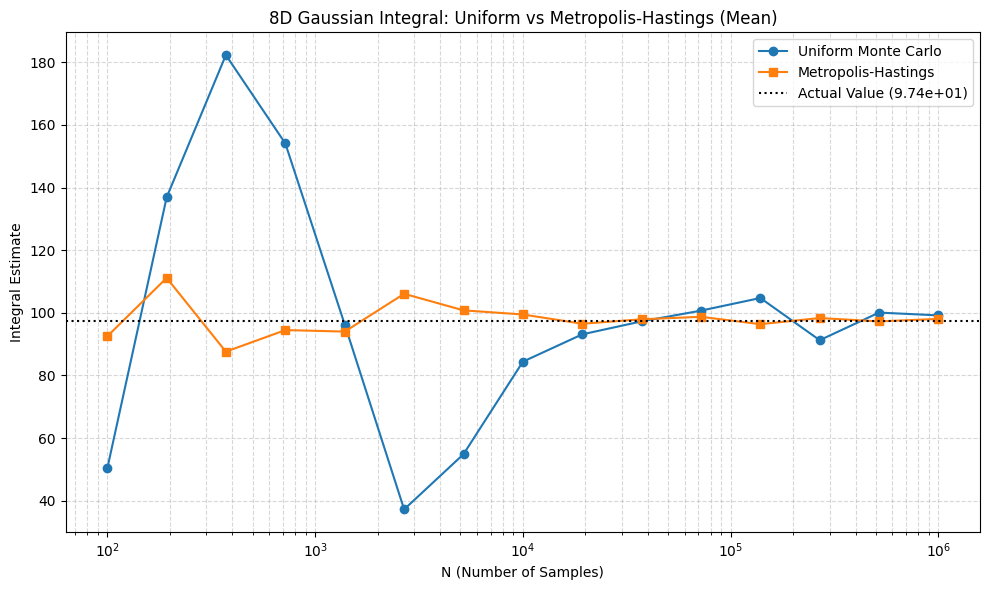

In [25]:

# Plotting (means only, no error bars)
plt.figure(figsize=(10, 6))
plt.plot(N_values, uniform_means, marker='o', label='Uniform Monte Carlo', color='tab:blue')
plt.plot(N_values, mh_means, marker='s', label='Metropolis-Hastings', color='tab:orange')
plt.axhline(actual_value, color='k', linestyle=':', label=f'Actual Value ({actual_value:.2e})')
plt.xscale('log')
plt.xlabel('N (Number of Samples)')
plt.ylabel('Integral Estimate')
plt.title('8D Gaussian Integral: Uniform vs Metropolis-Hastings (Mean)')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()